# 02 — With PM vs. without PM

With PM: an arbitrageur + organic swap flow trade against PM's declared WETH/USDC curve (`pm_fee=2%`, the profitable fee tier found below). Without PM: WETH balance never moves.

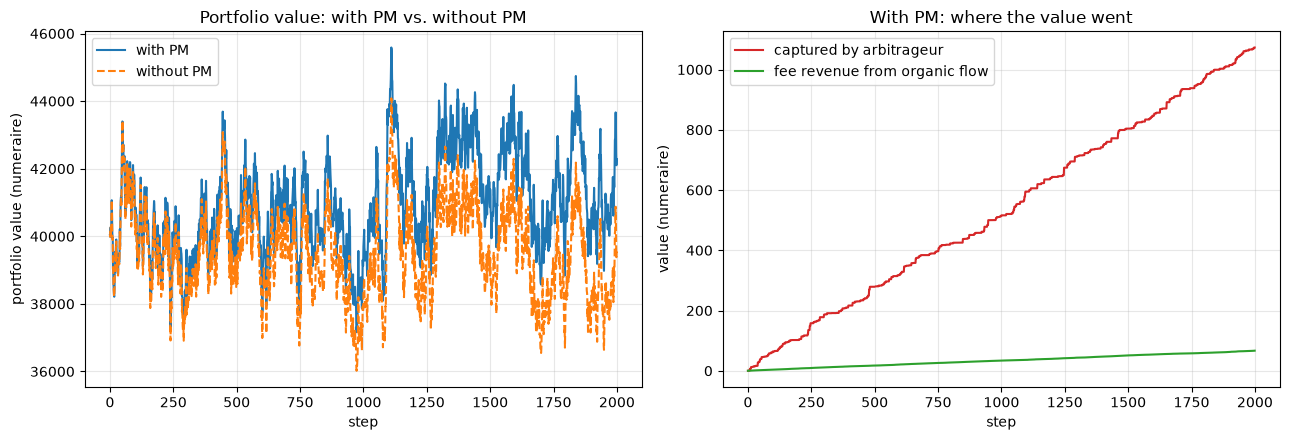

final value: with PM = 42,284, without PM = 39,551


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from aqua_sim.scenarios import basket_with_without_pm
from aqua_sim.price_process import MeanRevertingPriceProcess

N_STEPS = 2000
PROFITABLE_PM = dict(pm_fee=0.02, organic_arrival_prob_per_step=0.8, organic_fee=0.003, organic_mean_size_fraction=0.001)


def run_pair(seed, **kwargs):
    mr_with = MeanRevertingPriceProcess(token_id="WETH", sigma_per_step=0.02, mean_price=2000.0, kappa=0.05, initial_price=2000.0, seed=seed)
    world_with = basket_with_without_pm.build_world(with_pm=True, weth_price_process=mr_with, seed=seed, **PROFITABLE_PM, **kwargs)
    world_with.run(N_STEPS)

    mr_without = MeanRevertingPriceProcess(token_id="WETH", sigma_per_step=0.02, mean_price=2000.0, kappa=0.05, initial_price=2000.0, seed=seed)
    world_without = basket_with_without_pm.build_world(with_pm=False, weth_price_process=mr_without, seed=seed, **kwargs)
    world_without.run(N_STEPS)
    return world_with, world_without


def plot_comparison(world_with, world_without, title):
    total_with = np.array(world_with.metrics.value_a_path) + np.array(world_with.metrics.value_b_path)
    total_without = np.array(world_without.metrics.value_a_path) + np.array(world_without.metrics.value_b_path)
    arb_captured = np.array(world_with.metrics.captured_value_paths["arbitrageur"])
    organic_captured = np.array(world_with.metrics.captured_value_paths["organic_weth_usdc"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    ax1.plot(total_with, label="with PM")
    ax1.plot(total_without, label="without PM", linestyle="--")
    ax1.set_xlabel("step")
    ax1.set_ylabel("portfolio value (numeraire)")
    ax1.set_title(title)
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(arb_captured, label="captured by arbitrageur", color="tab:red")
    ax2.plot(-organic_captured, label="fee revenue from organic flow", color="tab:green")
    ax2.set_xlabel("step")
    ax2.set_ylabel("value (numeraire)")
    ax2.set_title("With PM: where the value went")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"final value: with PM = {total_with[-1]:,.0f}, without PM = {total_without[-1]:,.0f}")


world_with, world_without = run_pair(seed=0)
plot_comparison(world_with, world_without, "Portfolio value: with PM vs. without PM")


In [2]:
final_with, final_without = [], []
for seed in range(10):
    w_with, w_without = run_pair(seed=seed)
    final_with.append(w_with.metrics.value_a_path[-1] + w_with.metrics.value_b_path[-1])
    final_without.append(w_without.metrics.value_a_path[-1] + w_without.metrics.value_b_path[-1])

final_with, final_without = np.array(final_with), np.array(final_without)
print(f"mean final value: with PM = {final_with.mean():,.0f}, without PM = {final_without.mean():,.0f}")
print(f"with PM wins {int((final_with > final_without).sum())}/10 seeds")


mean final value: with PM = 42,791, without PM = 40,033
with PM wins 10/10 seeds


## Forced WETH uptrend

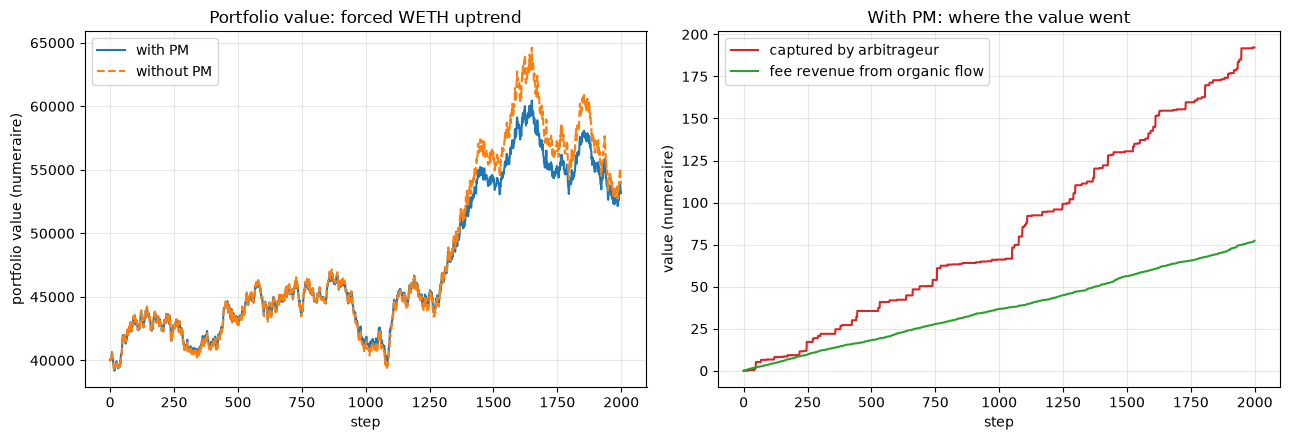

final value: with PM = 53,264, without PM = 54,121


In [3]:
def run_uptrend_pair(seed):
    world_with = basket_with_without_pm.build_world(with_pm=True, weth_drift_per_step=0.0006, seed=seed, **PROFITABLE_PM)
    world_with.run(N_STEPS)
    world_without = basket_with_without_pm.build_world(with_pm=False, weth_drift_per_step=0.0006, seed=seed)
    world_without.run(N_STEPS)
    return world_with, world_without


world_with_up, world_without_up = run_uptrend_pair(seed=0)
plot_comparison(world_with_up, world_without_up, "Portfolio value: forced WETH uptrend")


Impermanent loss — inherent to weighted rebalancing, not fixable by fee/gas tuning.